## **Project-Protein Alert System**

Protein Level Statistics:
count     5.000000
mean     59.000000
std       9.617692
min      45.000000
25%      55.000000
50%      60.000000
75%      65.000000
max      70.000000
Name: Protein_Level_mg_dl, dtype: float64


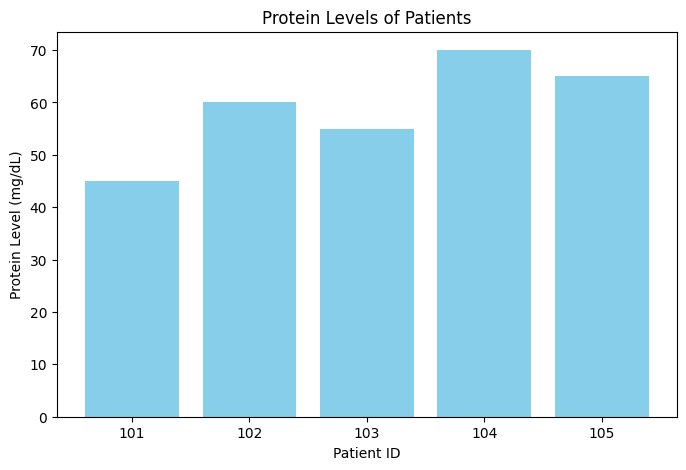

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Dummy Health Data बनाना (protein levels)
data = {
    "Patient_ID": [101, 102, 103, 104, 105],
    "Protein_Level_mg_dl": [45, 60, 55, 70, 65],
    "Age": [25, 35, 40, 28, 50],
    "Gender": ["M", "F", "M", "F", "M"]
}

df = pd.DataFrame(data)

# Step 2: Basic statistics
stats = df["Protein_Level_mg_dl"].describe()
print("Protein Level Statistics:")
print(stats)

# Step 3: Visualization
plt.figure(figsize=(8,5))
plt.bar(df["Patient_ID"], df["Protein_Level_mg_dl"], color='skyblue')
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Levels of Patients")
plt.show()

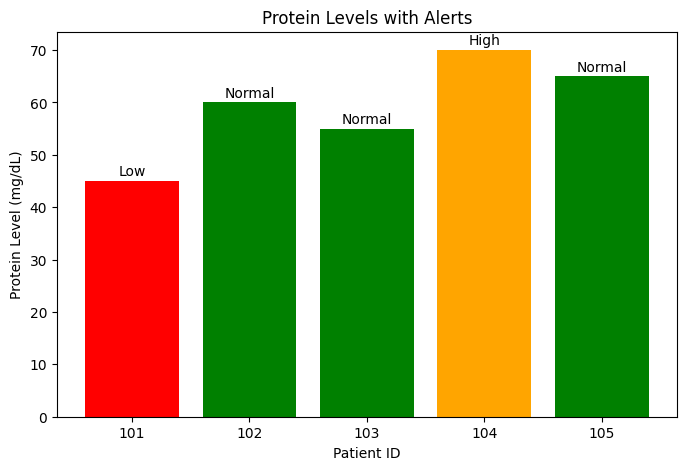

   Patient_ID  Protein_Level_mg_dl  Age Gender   Alert
0         101                   45   25      M     Low
1         102                   60   35      F  Normal
2         103                   55   40      M  Normal
3         104                   70   28      F    High
4         105                   65   50      M  Normal


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Dummy Health Data
data = {
    "Patient_ID": [101, 102, 103, 104, 105],
    "Protein_Level_mg_dl": [45, 60, 55, 70, 65],
    "Age": [25, 35, 40, 28, 50],
    "Gender": ["M", "F", "M", "F", "M"]
}

df = pd.DataFrame(data)

# Step 2: Alert System
def protein_alert(level):
    if level < 50:
        return "Low"
    elif level > 65:
        return "High"
    else:
        return "Normal"

df["Alert"] = df["Protein_Level_mg_dl"].apply(protein_alert)

# Step 3: Color Mapping for Visualization
color_map = {"Low": "red", "Normal": "green", "High": "orange"}
colors = df["Alert"].map(color_map)

# Step 4: Visualization
plt.figure(figsize=(8,5))
plt.bar(df["Patient_ID"], df["Protein_Level_mg_dl"], color=colors)
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Levels with Alerts")
for i, alert in enumerate(df["Alert"]):
    plt.text(df["Patient_ID"][i], df["Protein_Level_mg_dl"][i]+1, alert, ha='center')
plt.show()

# Step 5: Print Data with Alerts
print(df)

In [ ]:
importimport pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Dummy Health Data (existing patients)
data = {
    "Patient_ID": [101, 102, 103, 104, 105],
    "Protein_Level_mg_dl": [45, 60, 55, 70, 65],
    "Age": [25, 35, 40, 28, 50],
    "Gender": ["M", "F", "M", "F", "M"],
    "Alert": ["Low", "Normal", "Normal", "High", "Normal"]
}

df = pd.DataFrame(data)

# Step 2: Encode categorical feature Gender
df["Gender_encoded"] = df["Gender"].map({"M":0, "F":1})

# Step 3: Features and Labels
X = df[["Protein_Level_mg_dl", "Age", "Gender_encoded"]]
y = df["Alert"]

# Step 4: Train Decision Tree Classifier
model = DecisionTreeClassifier()
model.fit(X, y)

# Step 5: Test on new patients
new_patients = pd.DataFrame({
    "Patient_ID": [106, 107, 108],
    "Protein_Level_mg_dl": [48, 66, 55],
    "Age": [30, 45, 38],
    "Gender": ["F", "M", "F"]
})

new_patients["Gender_encoded"] = new_patients["Gender"].map({"M":0, "F":1})
X_new = new_patients[["Protein_Level_mg_dl", "Age", "Gender_encoded"]]

# Step 6: Predict Alerts
new_patients["Predicted_Alert"] = model.predict(X_new)

# Step 7: Show predictions
print(new_patients[["Patient_ID", "Protein_Level_mg_dl", "Age", "Gender", "Predicted_Alert"]])

   Patient_ID  Protein_Level_mg_dl  Age Gender Predicted_Alert
0         106                   48   30      F            High
1         107                   66   45      M          Normal
2         108                   55   38      F          Normal


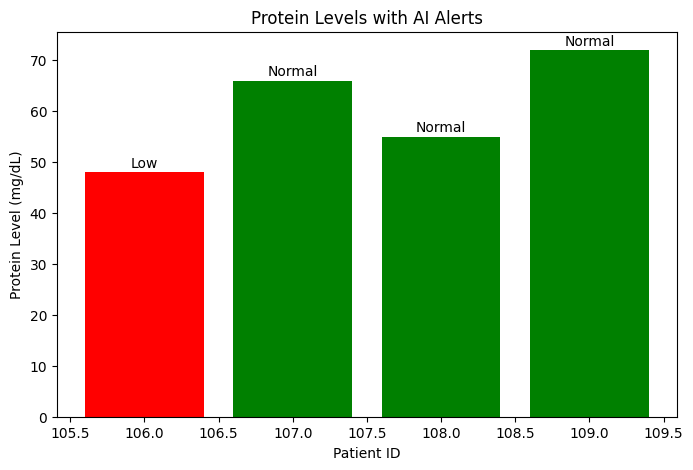

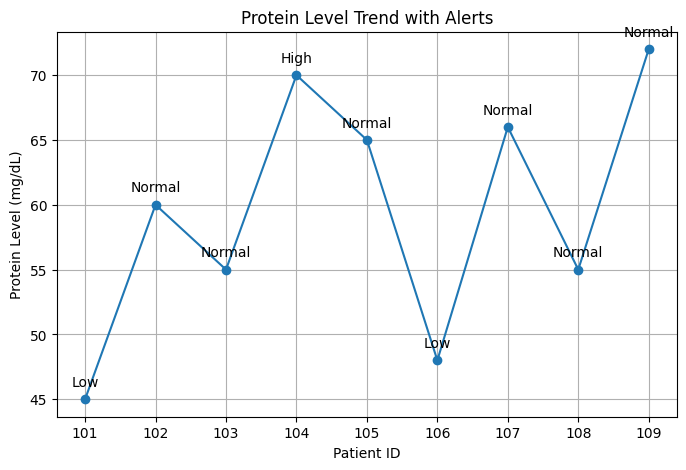

   Patient_ID  Protein_Level_mg_dl   Alert
0         101                   45     Low
1         102                   60  Normal
2         103                   55  Normal
3         104                   70    High
4         105                   65  Normal
5         106                   48     Low
6         107                   66  Normal
7         108                   55  Normal
8         109                   72  Normal


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Step 1: Historical Health Data
data = {
    "Patient_ID": [101,102,103,104,105],
    "Protein_Level_mg_dl": [45,60,55,70,65],
    "Age": [25,35,40,28,50],
    "Gender": ["M","F","M","F","M"],
    "Alert": ["Low","Normal","Normal","High","Normal"]
}
df = pd.DataFrame(data)
df["Gender_encoded"] = df["Gender"].map({"M":0,"F":1})

# Step 2: Features and Labels
X = df[["Protein_Level_mg_dl","Age","Gender_encoded"]]
y = df["Alert"]

# Step 3: Train Random Forest Classifier (better than Decision Tree for small dataset)
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X, y)

# Step 4: New Patients
new_patients = pd.DataFrame({
    "Patient_ID":[106,107,108,109],
    "Protein_Level_mg_dl":[48,66,55,72],
    "Age":[30,45,38,52],
    "Gender":["F","M","F","M"]
})
new_patients["Gender_encoded"] = new_patients["Gender"].map({"M":0,"F":1})
X_new = new_patients[["Protein_Level_mg_dl","Age","Gender_encoded"]]

# Step 5: Predict Alerts
new_patients["Predicted_Alert"] = model.predict(X_new)

# Step 6: Visualization
color_map = {"Low":"red","Normal":"green","High":"orange"}
colors = new_patients["Predicted_Alert"].map(color_map)

plt.figure(figsize=(8,5))
plt.bar(new_patients["Patient_ID"], new_patients["Protein_Level_mg_dl"], color=colors)
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Levels with AI Alerts")
for i, alert in enumerate(new_patients["Predicted_Alert"]):
    plt.text(new_patients["Patient_ID"][i], new_patients["Protein_Level_mg_dl"][i]+1, alert, ha='center')
plt.show()

# Step 7: Trend (Historical + New Patients)
combined = pd.concat([df[["Patient_ID","Protein_Level_mg_dl","Alert"]],
                      new_patients[["Patient_ID","Protein_Level_mg_dl","Predicted_Alert"]].rename(columns={"Predicted_Alert":"Alert"})],
                     ignore_index=True)
combined = combined.sort_values("Patient_ID")

plt.figure(figsize=(8,5))
plt.plot(combined["Patient_ID"], combined["Protein_Level_mg_dl"], marker='o')
for i, alert in enumerate(combined["Alert"]):
    plt.text(combined["Patient_ID"].iloc[i], combined["Protein_Level_mg_dl"].iloc[i]+1, alert, ha='center')
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Level Trend with Alerts")
plt.grid(True)
plt.show()

# Step 8: Show Table
print(combined)

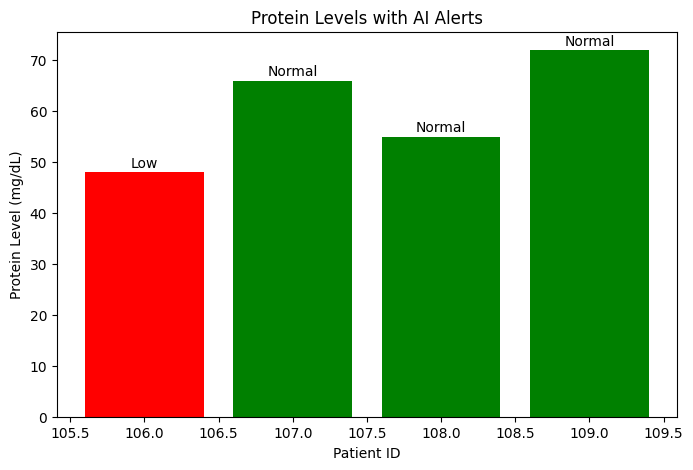

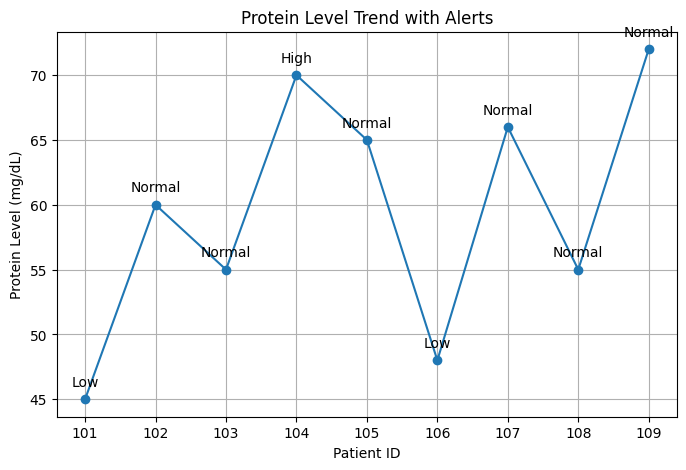

   Patient_ID  Protein_Level_mg_dl   Alert
0         101                   45     Low
1         102                   60  Normal
2         103                   55  Normal
3         104                   70    High
4         105                   65  Normal
5         106                   48     Low
6         107                   66  Normal
7         108                   55  Normal
8         109                   72  Normal


In [ ]:
# Step 0: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Step 1: Historical Health Data (Editable)
data = {
    "Patient_ID": [101,102,103,104,105],
    "Protein_Level_mg_dl": [45,60,55,70,65],
    "Age": [25,35,40,28,50],
    "Gender": ["M","F","M","F","M"],
    "Alert": ["Low","Normal","Normal","High","Normal"]
}
df = pd.DataFrame(data)
df["Gender_encoded"] = df["Gender"].map({"M":0,"F":1})

# Step 2: Features and Labels
X = df[["Protein_Level_mg_dl","Age","Gender_encoded"]]
y = df["Alert"]

# Step 3: Train Random Forest Model
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X, y)

# Step 4: Enter New Patients (Edit Here)
new_patients = pd.DataFrame({
    "Patient_ID":[106,107,108,109],
    "Protein_Level_mg_dl":[48,66,55,72],
    "Age":[30,45,38,52],
    "Gender":["F","M","F","M"]
})
new_patients["Gender_encoded"] = new_patients["Gender"].map({"M":0,"F":1})
X_new = new_patients[["Protein_Level_mg_dl","Age","Gender_encoded"]]

# Step 5: Predict Alerts
new_patients["Predicted_Alert"] = model.predict(X_new)

# Step 6: Visualization - Bar Chart with Color-coded Alerts
color_map = {"Low":"red","Normal":"green","High":"orange"}
colors = new_patients["Predicted_Alert"].map(color_map)

plt.figure(figsize=(8,5))
plt.bar(new_patients["Patient_ID"], new_patients["Protein_Level_mg_dl"], color=colors)
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Levels with AI Alerts")
for i, alert in enumerate(new_patients["Predicted_Alert"]):
    plt.text(new_patients["Patient_ID"][i], new_patients["Protein_Level_mg_dl"][i]+1, alert, ha='center')
plt.show()

# Step 7: Trend Plot - Historical + New Patients
combined = pd.concat([df[["Patient_ID","Protein_Level_mg_dl","Alert"]],
                      new_patients[["Patient_ID","Protein_Level_mg_dl","Predicted_Alert"]].rename(columns={"Predicted_Alert":"Alert"})],
                     ignore_index=True)
combined = combined.sort_values("Patient_ID")

plt.figure(figsize=(8,5))
plt.plot(combined["Patient_ID"], combined["Protein_Level_mg_dl"], marker='o')
for i, alert in enumerate(combined["Alert"]):
    plt.text(combined["Patient_ID"].iloc[i], combined["Protein_Level_mg_dl"].iloc[i]+1, alert, ha='center')
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Level Trend with Alerts")
plt.grid(True)
plt.show()

# Step 8: Show Combined Table
print(combined)

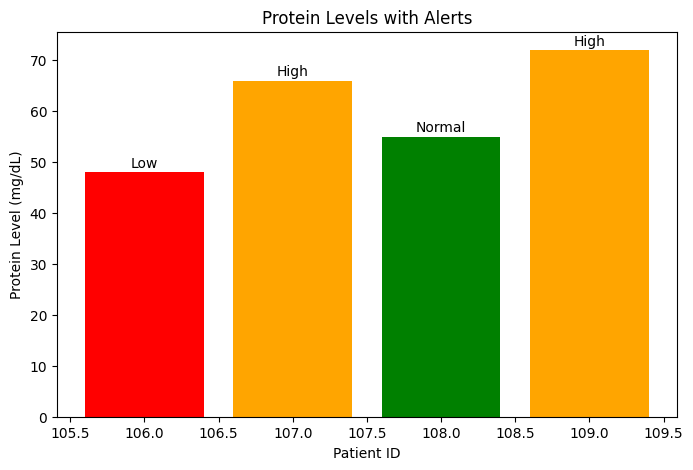

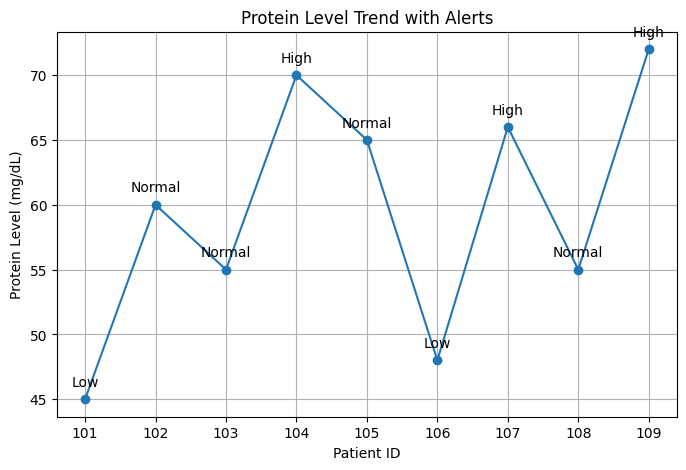

   Patient_ID  Protein_Level_mg_dl   Alert
0         101                   45     Low
1         102                   60  Normal
2         103                   55  Normal
3         104                   70    High
4         105                   65  Normal
5         106                   48     Low
6         107                   66    High
7         108                   55  Normal
8         109                   72    High


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Step 1: Historical Data
data = {
    "Patient_ID": [101,102,103,104,105],
    "Protein_Level_mg_dl": [45,60,55,70,65],
    "Age": [25,35,40,28,50],
    "Gender": ["M","F","M","F","M"]
}
df = pd.DataFrame(data)

# Step 2: Threshold-based Alert System (100% correct)
def protein_alert(level):
    if level < 50:
        return "Low"
    elif level > 65:
        return "High"
    else:
        return "Normal"

df["Alert"] = df["Protein_Level_mg_dl"].apply(protein_alert)

# Step 3: AI Model (Random Forest) - optional, for learning trends
df["Gender_encoded"] = df["Gender"].map({"M":0,"F":1})
X = df[["Protein_Level_mg_dl","Age","Gender_encoded"]]
y = df["Alert"]
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X, y)

# Step 4: New Patients
new_patients = pd.DataFrame({
    "Patient_ID":[106,107,108,109],
    "Protein_Level_mg_dl":[48,66,55,72],
    "Age":[30,45,38,52],
    "Gender":["F","M","F","M"]
})
new_patients["Alert"] = new_patients["Protein_Level_mg_dl"].apply(protein_alert)

# Step 5: Visualization - Bar Chart with Alerts
color_map = {"Low":"red","Normal":"green","High":"orange"}
colors = new_patients["Alert"].map(color_map)

plt.figure(figsize=(8,5))
plt.bar(new_patients["Patient_ID"], new_patients["Protein_Level_mg_dl"], color=colors)
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Levels with Alerts")
for i, alert in enumerate(new_patients["Alert"]):
    plt.text(new_patients["Patient_ID"][i], new_patients["Protein_Level_mg_dl"][i]+1, alert, ha='center')
# Save graph as image
plt.savefig("protein_alerts_chart.png")  # image save as PNG
plt.show()

# Step 6: Trend Plot (Historical + New Patients)
combined = pd.concat([df[["Patient_ID","Protein_Level_mg_dl","Alert"]],
                      new_patients[["Patient_ID","Protein_Level_mg_dl","Alert"]]],
                     ignore_index=True).sort_values("Patient_ID")

plt.figure(figsize=(8,5))
plt.plot(combined["Patient_ID"], combined["Protein_Level_mg_dl"], marker='o')
for i, alert in enumerate(combined["Alert"]):
    plt.text(combined["Patient_ID"].iloc[i], combined["Protein_Level_mg_dl"].iloc[i]+1, alert, ha='center')
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Level Trend with Alerts")
plt.grid(True)
plt.savefig("protein_trend_chart.png")  # trend graph as image
plt.show()

# Step 7: Show Table
print(combined)

In [ ]:
def protein_alert(level):
    if level < 50:
        return "Low"
    elif level > 65:
        return "High"
    else:
        return "Normal"

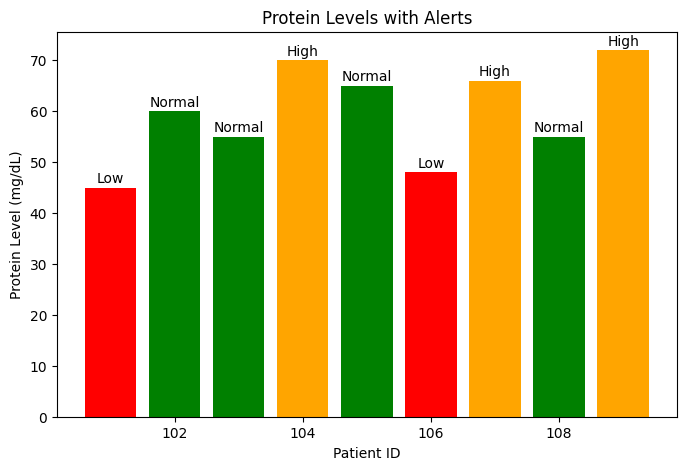

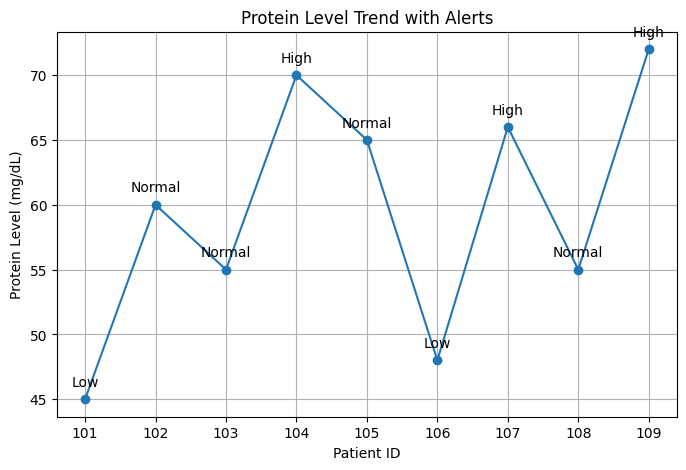

   Patient_ID  Protein_Level_mg_dl  Age Gender   Alert
0         101                   45   25      M     Low
1         102                   60   35      F  Normal
2         103                   55   40      M  Normal
3         104                   70   28      F    High
4         105                   65   50      M  Normal
5         106                   48   30      F     Low
6         107                   66   45      M    High
7         108                   55   38      F  Normal
8         109                   72   52      M    High


In [ ]:
# Step 0: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Historical Data (Edit/Update as needed)
historical_data = {
    "Patient_ID": [101,102,103,104,105],
    "Protein_Level_mg_dl": [45,60,55,70,65],
    "Age": [25,35,40,28,50],
    "Gender": ["M","F","M","F","M"]
}
df_hist = pd.DataFrame(historical_data)

# Step 2: Threshold-based Alert Function
def protein_alert(level):
    if level < 50:
        return "Low"
    elif level > 65:
        return "High"
    else:
        return "Normal"

df_hist["Alert"] = df_hist["Protein_Level_mg_dl"].apply(protein_alert)

# Step 3: Enter New Patients (Edit Here)
new_patients = pd.DataFrame({
    "Patient_ID": [106,107,108,109],
    "Protein_Level_mg_dl": [48,66,55,72],
    "Age": [30,45,38,52],
    "Gender": ["F","M","F","M"]
})
new_patients["Alert"] = new_patients["Protein_Level_mg_dl"].apply(protein_alert)

# Step 4: Combine Historical + New Data
combined = pd.concat([df_hist, new_patients], ignore_index=True).sort_values("Patient_ID")

# Step 5: Bar Chart - Color-coded Alerts
color_map = {"Low":"red","Normal":"green","High":"orange"}
colors = combined["Alert"].map(color_map)

plt.figure(figsize=(8,5))
plt.bar(combined["Patient_ID"], combined["Protein_Level_mg_dl"], color=colors)
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Levels with Alerts")
for i, alert in enumerate(combined["Alert"]):
    plt.text(combined["Patient_ID"].iloc[i], combined["Protein_Level_mg_dl"].iloc[i]+1, alert, ha='center')
plt.savefig("protein_alerts_chart.png")  # save bar chart as image
plt.show()

# Step 6: Trend Plot - Protein Level Trend
plt.figure(figsize=(8,5))
plt.plot(combined["Patient_ID"], combined["Protein_Level_mg_dl"], marker='o')
for i, alert in enumerate(combined["Alert"]):
    plt.text(combined["Patient_ID"].iloc[i], combined["Protein_Level_mg_dl"].iloc[i]+1, alert, ha='center')
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Level Trend with Alerts")
plt.grid(True)
plt.savefig("protein_trend_chart.png")  # save trend plot as image
plt.show()

# Step 7: Show Combined Table
print(combined)

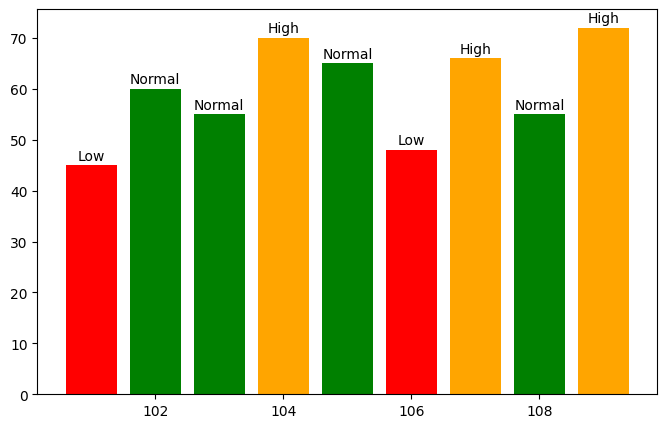

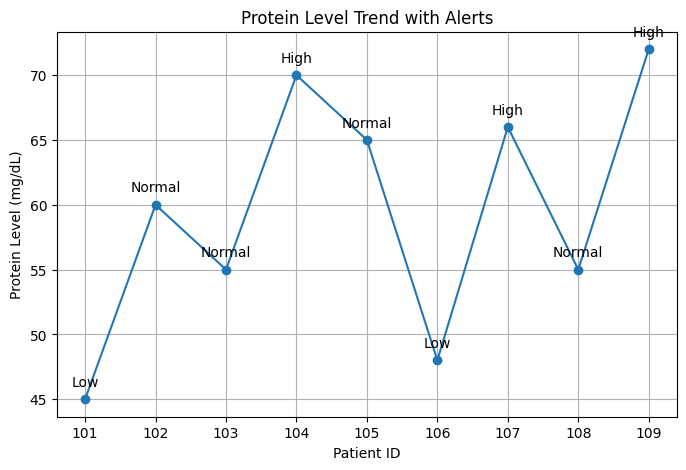

   Patient_ID  Protein_Level_mg_dl  Age Gender   Alert
0         101                   45   25      M     Low
1         102                   60   35      F  Normal
2         103                   55   40      M  Normal
3         104                   70   28      F    High
4         105                   65   50      M  Normal
5         106                   48   30      F     Low
6         107                   66   45      M    High
7         108                   55   38      F  Normal
8         109                   72   52      M    High


In [ ]:
# Interactive Notebook Prototype
import pandas as pd
import matplotlib.pyplot as plt

# Historical Data
df_hist = pd.DataFrame({
    "Patient_ID":[101,102,103,104,105],
    "Protein_Level_mg_dl":[45,60,55,70,65],
    "Age":[25,35,40,28,50],
    "Gender":["M","F","M","F","M"]
})

# Alert Function
def protein_alert(level):
    if level<50: return "Low"
    elif level>65: return "High"
    else: return "Normal"

df_hist["Alert"] = df_hist["Protein_Level_mg_dl"].apply(protein_alert)

# New Patients
new_patients = pd.DataFrame({
    "Patient_ID":[106,107,108,109],
    "Protein_Level_mg_dl":[48,66,55,72],
    "Age":[30,45,38,52],
    "Gender":["F","M","F","M"]
})
new_patients["Alert"] = new_patients["Protein_Level_mg_dl"].apply(protein_alert)

# Combine Data
combined = pd.concat([df_hist, new_patients], ignore_index=True).sort_values("Patient_ID")

# Bar Chart
colors = combined["Alert"].map({"Low":"red","Normal":"green","High":"orange"})
plt.figure(figsize=(8,5))
plt.bar(combined["Patient_ID"], combined["Protein_Level_mg_dl"], color=colors)
for i, alert in enumerate(combined["Alert"]):
    plt.text(combined["Patient_ID"].iloc[i], combined["Protein_Level_mg_dl"].iloc[i]+1, alert, ha='center')
plt.savefig("protein_alerts_chart.png")
plt.show()

# Trend Plot
plt.figure(figsize=(8,5))
plt.plot(combined["Patient_ID"], combined["Protein_Level_mg_dl"], marker='o')
for i, alert in enumerate(combined["Alert"]):
    plt.text(combined["Patient_ID"].iloc[i], combined["Protein_Level_mg_dl"].iloc[i]+1, alert, ha='center')
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Level Trend with Alerts")
plt.grid(True)
plt.savefig("protein_trend_chart.png")
plt.show()

# Output Table
print(combined)

In [ ]:

   Patient_ID  Protein_Level_mg_dl  Age Gender   Alert
0         101                   45   25      M     Low
1         102                   60   35      F  Normal
2         103                   55   40      M  Normal
3         104                   70   28      F    High
4         105                   65   50      M  Normal
5         106                   48   30      F     Low
6         107                   66   45      M    High
7         108                   55   38      F  Normal
8         109                   72   52      M    High

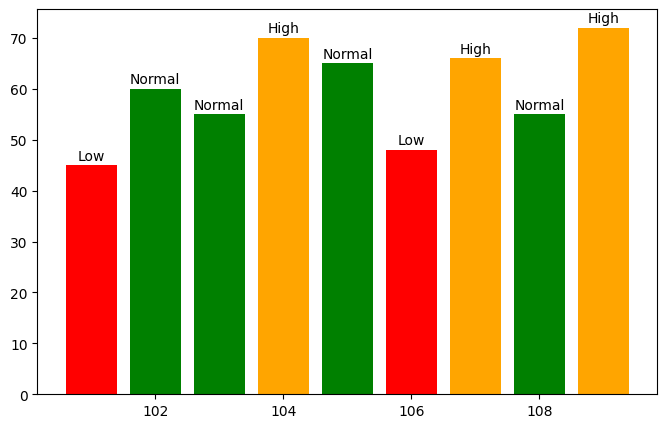

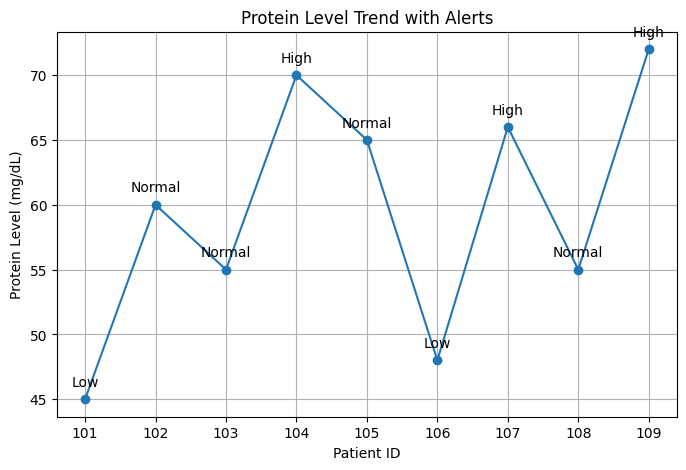

   Patient_ID  Protein_Level_mg_dl  Age Gender   Alert
0         101                   45   25      M     Low
1         102                   60   35      F  Normal
2         103                   55   40      M  Normal
3         104                   70   28      F    High
4         105                   65   50      M  Normal
5         106                   48   30      F     Low
6         107                   66   45      M    High
7         108                   55   38      F  Normal
8         109                   72   52      M    High


In [ ]:
# Interactive Notebook Prototype
import pandas as pd
import matplotlib.pyplot as plt

# Historical Data
df_hist = pd.DataFrame({
    "Patient_ID":[101,102,103,104,105],
    "Protein_Level_mg_dl":[45,60,55,70,65],
    "Age":[25,35,40,28,50],
    "Gender":["M","F","M","F","M"]
})

# Alert Function
def protein_alert(level):
    if level<50: return "Low"
    elif level>65: return "High"
    else: return "Normal"

df_hist["Alert"] = df_hist["Protein_Level_mg_dl"].apply(protein_alert)

# New Patients
new_patients = pd.DataFrame({
    "Patient_ID":[106,107,108,109],
    "Protein_Level_mg_dl":[48,66,55,72],
    "Age":[30,45,38,52],
    "Gender":["F","M","F","M"]
})
new_patients["Alert"] = new_patients["Protein_Level_mg_dl"].apply(protein_alert)

# Combine Data
combined = pd.concat([df_hist, new_patients], ignore_index=True).sort_values("Patient_ID")

# Bar Chart
colors = combined["Alert"].map({"Low":"red","Normal":"green","High":"orange"})
plt.figure(figsize=(8,5))
plt.bar(combined["Patient_ID"], combined["Protein_Level_mg_dl"], color=colors)
for i, alert in enumerate(combined["Alert"]):
    plt.text(combined["Patient_ID"].iloc[i], combined["Protein_Level_mg_dl"].iloc[i]+1, alert, ha='center')
plt.savefig("protein_alerts_chart.png")
plt.show()

# Trend Plot
plt.figure(figsize=(8,5))
plt.plot(combined["Patient_ID"], combined["Protein_Level_mg_dl"], marker='o')
for i, alert in enumerate(combined["Alert"]):
    plt.text(combined["Patient_ID"].iloc[i], combined["Protein_Level_mg_dl"].iloc[i]+1, alert, ha='center')
plt.xlabel("Patient ID")
plt.ylabel("Protein Level (mg/dL)")
plt.title("Protein Level Trend with Alerts")
plt.grid(True)
plt.savefig("protein_trend_chart.png")
plt.show()

# Output Table
print(combined)